# 08 - Simulation Intro


This notebook introduces the `e.simulation` namespace with one measured Ar fit, one measured 2.8 M PhOH EEC' fit, and a simulated scan-rate sweep from the fitted PhOH model. Group fitting across multiple CVs now lives in `09_group_fitting.ipynb`.


## Import eCAT And Set Paths

Simulation examples use the packaged Fe/PhOH CV data for fit-ready measured-current inputs.


In [1]:
from copy import deepcopy
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


def display_path(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except ValueError:
        return path.name

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import ecat as e

DATA_DIR = ROOT / "examples" / "data" / "fe_phoh_cv"
EXPORT_DIR = ROOT / "notebooks" / "_outputs"
EXPORT_DIR.mkdir(exist_ok=True)

e.plotting_style("notebook")
print("eCAT version:", getattr(e, "__version__", "unknown"))
print("Example data:", display_path(DATA_DIR))
print("Text files:", len(list(DATA_DIR.glob("*.txt"))))


eCAT version: 0.1.0b2
Example data: examples/data/fe_phoh_cv
Text files: 13


## Load And Select Real CV Inputs

Use eCAT filters so the simulation inputs are traceable. Ar CVs use the `0` to `-1.5 V` fitting window; PhOH CVs use expanded waveform trimming from `-1` to `-1.7 V` before fitting and simulation.


In [2]:
cvs = e.get_data({
    "folder path": str(DATA_DIR),
    "reference mode": "keyword",
    "reference keyword": "Fc",
    "reference guess": 0.4,
    "reference label": "Fc/Fc+",
    "electrode diameter": 0.3,
    "print": False,
})
cvs = e.filter(cvs, {"segments": 3}, {"print": False})

fe_ar = e.filter(cvs, {
    "gas": "Ar",
    "compounds": "Fe-tpyPY2Me",
}, {"logic": "AND", "print": False})

phoh_co2 = e.filter(cvs, {
    "gas": "CO2",
    "compounds": "PhOH",
}, {"logic": "AND", "print": False})

scan_series = e.filter(fe_ar, {
    "scan window": [-1.7, 1],
}, {"print": False})
scan_series = e.sort(scan_series, "scan rate", {"print": False})

ar_reference_cv = e.filter(scan_series, {"scan rate": 0.1}, {"print": False})[0]
phoh_group = e.filter(phoh_co2, {"scan rate": 0.1}, {"print": False})
phoh_28m_cv = e.filter(phoh_group, {"species": "2.8M PhOH"}, {"print": False})[0]

AR_CV_POTENTIAL_WINDOW = [-0.7, -1.7]
PHOH_CV_POTENTIAL_WINDOW = [-1.0, -1.7]
AR_CV_WINDOW_OPTIONS = {
    "potential window": AR_CV_POTENTIAL_WINDOW,
    "trim mode": "expand",
}
PHOH_CV_WINDOW_OPTIONS = {
    "potential window": PHOH_CV_POTENTIAL_WINDOW,
    "trim mode": "expand",
}

e.show_objects([ar_reference_cv, phoh_28m_cv], {
    "columns": ["gas", "scan rate", "compounds", "scan window"],
});


Searching recursively through:
 examples/data/fe_phoh_cv
13 .txt files found.

Reference correction:
  Mode: keyword
  Keyword: Fc
  Guess: 0.4 V
  Folder reference: MeCN_Ar_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_-1.2_to_1V_100mVs.txt = 0.4665 V
  Usage:
    folder/ancestor reference: 3
    self-referenced successfully: 10

[Conditions] Exp Type: CV, Solvent: MeCN, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM Fe-tpyPY2Me, Scan Rate: 100 mV/s, Segments: 3, IR Comp Percent: 100 %


,Gas,Compounds,Scan Window,Scan Rate
[0],Ar,,"[-1.7, 1]",100 mV/s
[1],CO2,2.8 M PhOH,"[-1.2, 1]",100 mV/s


## Build A Programmatic CV Input

`cv_program()` returns a `SimulatedCVInput`. Use `.show()` for a setup table and `.plot()` to inspect the potential program. Quiet time is metadata and is drawn at negative time only when `plot quiet time` is enabled.


**Simulated CV Input Setup:**

,Parameter,Value
0,Source,program
1,Kind,cv_program
2,Points,599
3,Scan Rate,0.1 V/s
4,Segments,2
5,Quiet Time,5 s
6,Potential Range,-1.5 V to 0 V
7,Time Range,0 s to 30 s
8,Potential Unit,V
9,Current Unit,A


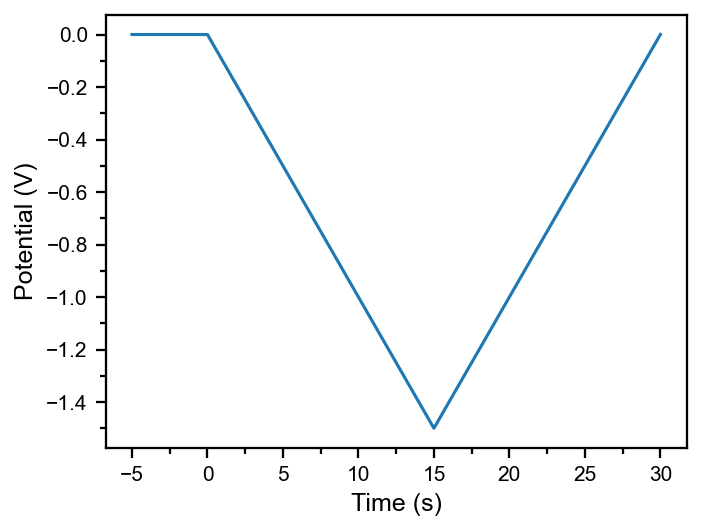

In [3]:
program = e.simulation.cv_program(
    Ei=0.0,
    E_low=-1.5,
    scan_rate=0.1,
    segments=2,
    points_per_segment=300,
    quiet_time=5,
)
program.show()
program.plot({"plot quiet time": True, "label": "Program + quiet time"});


## Convert A Real CV With `cv_data`

`cv_data()` makes a fit-ready simulation input from an eCAT `cv`. A larger `stride` keeps the tutorial quick while preserving the measured-current path.


**Simulated CV Input Setup:**

,Parameter,Value
0,Source,MeCN_CO2_0.1MTBAPF6_3mMFc_1mMFe-tpyPY2Me_2.8MPhOH_-1.2_to_1V_100mVs
1,Kind,cv_data
2,Points,74
3,Scan Rate,0.1 V/s
4,Segments,
5,Quiet Time,2 s
6,Potential Range,-1.711 V to -1 V
7,Time Range,0 s to 14.22 s
8,Current Range,-0.0001643 A to 2.105e-06 A
9,Potential Unit,V


<Axes: xlabel='Time (s)', ylabel='Potential (V vs $\\mathrm{Fc/Fc^{+}}$)'>

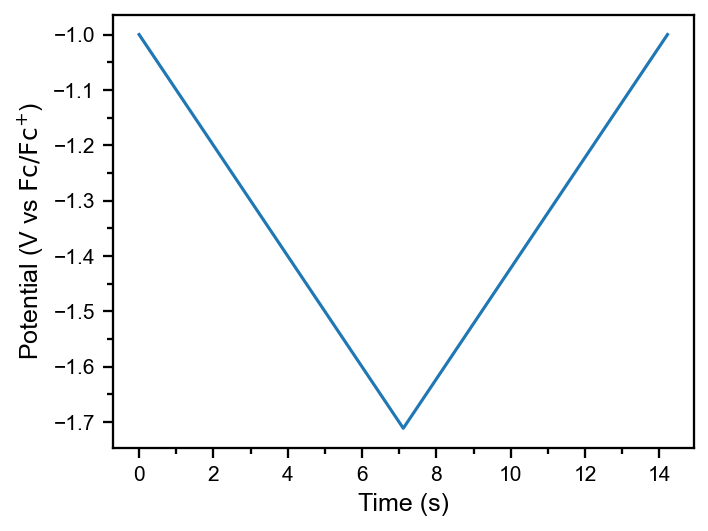

In [4]:
input_from_data = e.simulation.cv_data(phoh_28m_cv, {
    **PHOH_CV_WINDOW_OPTIONS,
    "stride": 20,
})
input_from_data.show()
input_from_data.plot()


## Backend Simulation

Run a simple simulated CV from the programmatic input. This requires the optional ElectroKitty simulation dependency.


**Simulation Parameter Checks:**

,Status,Path,Check,Detail
0,INFO,mechanism,Preset species order,"E preset uses species in order: a, b."


**Simulated CV Setup:**

,Parameter,Value
0,Backend,electrokitty
1,Mechanism Preset,E
2,Mechanism,E(1):a=b
3,Current Sign,1
4,Points,599
5,Scan Rate,0.1 V/s
6,Segments,2
7,Quiet Time,5 s
8,Potential Range,-1.5 V to 0 V
9,Current Range,-2.67487e-05 A to 2.21709e-05 A


**Simulation Params:**

...

,Group,Path,Parameter,Value
0,cell,cell.T,T,298.15 K
1,cell,cell.Ru,Rᵤ,0 Ω
2,cell,cell.Cdl,Cdl,0 F
3,cell,cell.A,A,1e-05 m²
4,spatial,spatial.dx_fraction,Δx/xmax,0.005
5,spatial,spatial.nx,nₓ,8
6,spatial,spatial.viscosity,η,1e-06 m²/s
7,spatial,spatial.rotation,ω,0 Hz


`species`

,Group,Path,Species,Parameter,Value
0,bulk,concentrations.bulk.a,a,[a],1 mol/m³
1,bulk,diffusion.a,a,D(a),1e-09 m²/s
2,bulk,concentrations.bulk.b,b,[b],0 mol/m³
3,bulk,diffusion.b,b,D(b),1e-09 m²/s


`mechanism`

,Group,Path,Parameter,Value
0,kinetics,kinetics.0.E0,E⁰,-0.8 V
1,kinetics,kinetics.0.k0,k⁰,0.001 m/s
2,kinetics,kinetics.0.alpha,α,0.5


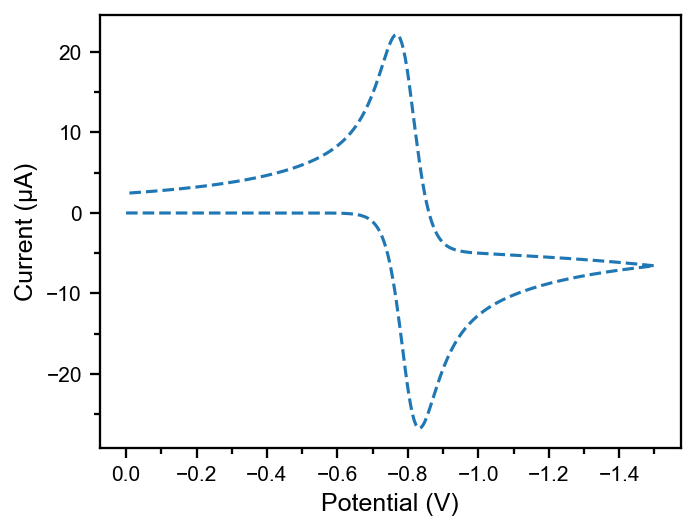

In [5]:
params = {
    "concentrations": {"bulk": {"a": 1.0, "b": 0.0}},
    "diffusion": {"a": 1e-9, "b": 1e-9},
    "kinetics": [{"E0": -0.8, "k0": 1e-3, "alpha": 0.5}],
    "cell": {"T": 298.15, "Ru": 0.0, "Cdl": 0.0, "A": 1e-5},
    "spatial": "fast",
}

result = e.simulation.simulate_cv(
    program,
    "E",
    params,
    options={"plot": True, "check params": True},
)
result.show({"print setup": True, "print params": True})


## Useful Simulation String Inputs

The fit examples below use a few string conveniences from the simulation test notebook. The spatial `fast` preset is used here for speed so the notebook is easy to rerun; use `balanced` or `accurate` for more careful production simulations.


In [6]:
def wrap_df(df, value_width="220px", meaning_width="360px"):
    return df.style.set_properties(
        **{"white-space": "normal", "text-align": "left"}
    ).set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("max-width", value_width)]},
        {"selector": "td.col2", "props": [("max-width", meaning_width)]},
    ])

simulation_string_inputs = pd.DataFrame([
    {"Where": "fit['vary']", "String": "E0_0", "Meaning": "formal potential for electron-transfer step 0"},
    {"Where": "fit['vary']", "String": "E0_1", "Meaning": "formal potential for electron-transfer step 1"},
    {"Where": "fit['vary']", "String": "D", "Meaning": "one tied diffusion coefficient when all diffusion values start equal"},
    {"Where": "fit['fixed']", "String": "alpha_*", "Meaning": "all kinetic alpha entries"},
    {"Where": "fit['fixed']", "String": "k0_*", "Meaning": "all heterogeneous electron-transfer rate constants"},
    {"Where": "params['kinetics'][...]['k0']", "String": "fast, reversible, rev", "Meaning": "k0 aliases that normalize to 1e-3 m/s"},
    {"Where": "params['kinetics'][...]['k0']", "String": "quasi, quasireversible, quasi reversible", "Meaning": "k0 aliases that normalize to 1e-5 m/s"},
    {"Where": "params['kinetics'][...]['k0']", "String": "slow, irreversible, irrev", "Meaning": "k0 aliases that normalize to 1e-8 m/s"},
    {"Where": "params['spatial']", "String": "fast, balanced, accurate", "Meaning": "spatial grid presets (see below)"},
    {"Where": "options", "String": "post correction = offset", "Meaning": "apply only a final vertical current offset after fitting"},
])

spatial_presets = (
    pd.DataFrame.from_dict(e.simulation.SPATIAL_PRESETS, orient="index")
    .rename_axis("preset")
    .reset_index()
    .rename(columns={
        "dx_fraction": "dx_fraction / dimensionless",
        "viscosity": "viscosity / m<sup>2</sup> s<sup>-1</sup>",
        "rotation": "rotation / Hz",
    })
)
spatial_presets["relative grid cost / fast=1"] = (
    spatial_presets["nx"] / spatial_presets["dx_fraction / dimensionless"]
)
spatial_presets["relative grid cost / fast=1"] /= spatial_presets.loc[
    spatial_presets["preset"] == "fast", "relative grid cost / fast=1"
].iloc[0]

spatial_style = (
    spatial_presets.style
    .format({
        "dx_fraction / dimensionless": "{:.3e}",
        "viscosity / m<sup>2</sup> s<sup>-1</sup>": "{:.3e}",
        "rotation / Hz": "{:.3e}",
        "relative grid cost / fast=1": "{:.1f}x",
    })
    .format_index(escape=None, axis=1)
)

display(wrap_df(simulation_string_inputs))
display(spatial_style)


,Where,String,Meaning
0,fit['vary'],E0_0,formal potential for electron-transfer step 0
1,fit['vary'],E0_1,formal potential for electron-transfer step 1
2,fit['vary'],D,one tied diffusion coefficient when all diffusion values start equal
3,fit['fixed'],alpha_*,all kinetic alpha entries
4,fit['fixed'],k0_*,all heterogeneous electron-transfer rate constants
5,params['kinetics'][...]['k0'],"fast, reversible, rev",k0 aliases that normalize to 1e-3 m/s
6,params['kinetics'][...]['k0'],"quasi, quasireversible, quasi reversible",k0 aliases that normalize to 1e-5 m/s
7,params['kinetics'][...]['k0'],"slow, irreversible, irrev",k0 aliases that normalize to 1e-8 m/s
8,params['spatial'],"fast, balanced, accurate",spatial grid presets (see below)
9,options,post correction = offset,apply only a final vertical current offset after fitting


,preset,dx_fraction / dimensionless,nx,viscosity / m2 s-1,rotation / Hz,relative grid cost / fast=1
0,fast,5.000e-03,8,1.000e-06,0.000e+00,1.0x
1,balanced,1.000e-03,12,1.000e-06,0.000e+00,7.5x
2,accurate,2.778e-05,20,1.000e-06,0.000e+00,450.0x


## Fit 1: Single Ar CV

Fit one Ar CV at `0.1 V/s` to get an `EE` starting point for the formal potentials and tied diffusion coefficient.


**Fitting Setup:**

`fit`

,Parameter,Control,Value
0,Fit strategy,method,least squares
1,Simulation backend,backend,electrokitty
2,Mechanism,mechanism,E(1):FeII=FeI ; E(1):FeI=Fe0
3,Mechanism preset,compile_mechanism(...).preset,EE
4,Residual mode,"options[""residual""]",direct
5,Final current correction,"options[""post correction""]",offset
6,Residual normalization,"options[""residual normalization""]",max abs measured
7,Evaluation budget,"options[""max nfev""]",None
8,Data points,input.E,198
9,Fit targets,"fit[""vary""]",3


`vary`

,Path,Step,Parameter,Initial,Lower,Upper,Transform
0,kinetics.0.E0,0,E⁰,-1.3 V,-2.1665 V,-0.7005 V,linear
1,kinetics.1.E0,1,E⁰,-1.5 V,-2.1665 V,-0.7005 V,linear
2,"diffusion.FeII, diffusion.FeI, diffusion.Fe0",,D (tied),2e-09 m²/s,2e-11 m²/s,2e-07 m²/s,log10


...

,Group,Path,Step,Parameter,Fit Status,Initial Value,Final Value
0,kinetics,kinetics.0.E0,0,E⁰,fit,-1.3 V,-1.37098 V
1,kinetics,kinetics.0.k0,0,k⁰,fixed,0.001 m/s,
2,kinetics,kinetics.0.alpha,0,α,fixed,0.5,
3,kinetics,kinetics.1.E0,1,E⁰,fit,-1.5 V,-1.46872 V
4,kinetics,kinetics.1.k0,1,k⁰,fixed,0.001 m/s,
5,kinetics,kinetics.1.alpha,1,α,fixed,0.5,


**Fitting Statistics:**

,Parameter,Value
0,Data Points,198
1,Fit Parameters,3
2,Degrees of Freedom,195
3,Objective Evaluations,47
4,Optimizer Cost,1.33944
5,Final Optimizer Cost,1.33944
6,Residual Norm,2.89973e-05 A
7,RMSE,2.06075e-06 A
8,MAE,1.35408e-06 A
9,Max |Residual|,7.78803e-06 A


**Fitting Corrections:**

,Parameter,Value
0,Current Sign,1
1,Baseline Intercept,-4.81281e-06 A


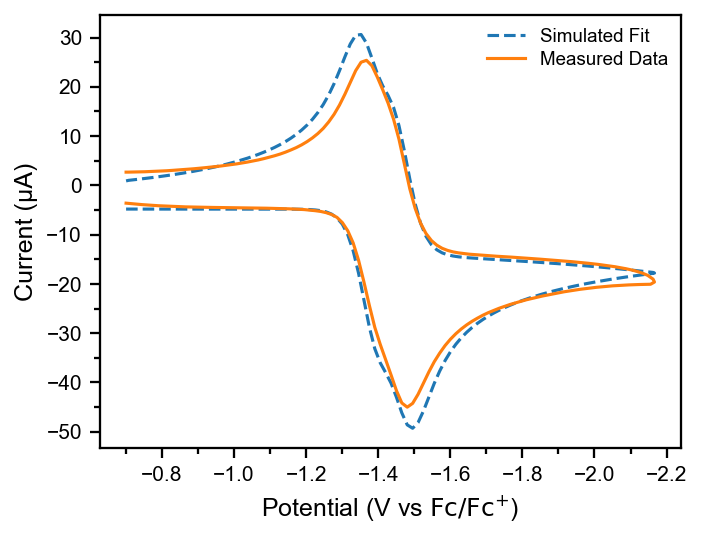

In [7]:
AR_FIT_STRIDE = 15
CO2_FIT_STRIDE = 15

ar_ee_params = {
    "concentrations": {"bulk": {"FeII": 1.0, "FeI": 0.0, "Fe0": 0.0}},
    "diffusion": {"FeII": 2e-9, "FeI": 2e-9, "Fe0": 2e-9},
    "kinetics": [
        {"E0": -1.3, "k0": 1e-3, "alpha": 0.5},
        {"E0": -1.5, "k0": 1e-3, "alpha": 0.5},
    ],
    "cell": {"T": 298.15, "Ru": 0.0, "Cdl": "auto", "A": 1e-5},
    "spatial": "fast",
}

single_ar_fit = e.simulation.fit_cv(
    ar_reference_cv,
    "EE",
    ar_ee_params,
    fit={
        "vary": ["E0_0", "E0_1", "D"],
        "fixed": {"alpha_*": 0.5, "k0_*": 1e-3},
        "bounds": "auto",
        "transform": "auto",
    },
    options={
        "cv data": {**AR_CV_WINDOW_OPTIONS, "stride": AR_FIT_STRIDE, "estimate Cdl": "auto"},
        "plot": True,
        "post correction": "offset",
        "print stats": False,
        "print corrections": False,
        "print progress": False,
    },
)
single_ar_fit.show({"print setup": False, "print stats": True, "print corrections": True, "print params": False, "print simulation": False})


## Fit 2: One 2.8 M PhOH EEC' CV

Use the Ar-fit parameters as the starting point. The PhOH concentration is mapped to the simulation species `Substrate`, and only the catalytic forward rate is varied in this tutorial fit.


**Fitting Setup:**

`fit`

,Parameter,Control,Value
0,Fit strategy,method,least squares
1,Simulation backend,backend,electrokitty
2,Mechanism,mechanism,E(1):FeII=FeI ; E(1):FeI=Fe0 ; C:Fe0+Substrate>FeI+Product
3,Mechanism preset,compile_mechanism(...).preset,raw
4,Residual mode,"options[""residual""]",direct
5,Final current correction,"options[""post correction""]",offset
6,Residual normalization,"options[""residual normalization""]",max abs measured
7,Evaluation budget,"options[""max nfev""]",None
8,Data points,input.E,97
9,Fit targets,"fit[""vary""]",1


`vary`

,Path,Parameter,Initial,Lower,Upper,Transform
0,reactions.0.kf,k₁,1 s⁻¹,1e-30 s⁻¹,1e+12 s⁻¹,log10


...

,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,cell,cell.Cdl,Cdl,fixed,2.32935e-05 F,
1,cell,cell.T,T,fixed,298 K,
2,cell,cell.A,A,fixed,7.06858e-06 m²,
3,cell,cell.Ru,Rᵤ,fixed,0 Ω,
4,spatial,spatial.dx_fraction,Δx/xmax,fixed,0.005,
5,spatial,spatial.nx,nₓ,fixed,8,
6,spatial,spatial.viscosity,η,fixed,4.7e-07 m²/s,
7,spatial,spatial.rotation,ω,fixed,0 Hz,
8,diffusion,diffusion.FeII,D(FeII),fixed,9.94596e-10 m²/s,
9,diffusion,diffusion.FeI,D(FeI),fixed,9.94596e-10 m²/s,


`species`

,Group,Path,Parameter,Fit Status,Initial Value,Final Value
0,bulk,concentrations.bulk.FeII,[FeII],fixed,1 mol/m³,
1,bulk,concentrations.bulk.FeI,[FeI],fixed,0 mol/m³,
2,bulk,concentrations.bulk.Fe0,[Fe0],fixed,0 mol/m³,
3,bulk,concentrations.bulk.Substrate,[Substrate],fixed,2800 mol/m³,
4,bulk,concentrations.bulk.Product,[Product],fixed,0 mol/m³,


`mechanism`

,Group,Path,Step,Parameter,Fit Status,Initial Value,Final Value
0,kinetics,kinetics.0.E0,0,E⁰,fixed,-1.37098 V,
1,kinetics,kinetics.0.k0,0,k⁰,fixed,0.001 m/s,
2,kinetics,kinetics.0.alpha,0,α,fixed,0.5,
3,kinetics,kinetics.1.E0,1,E⁰,fixed,-1.46872 V,
4,kinetics,kinetics.1.k0,1,k⁰,fixed,0.001 m/s,
5,kinetics,kinetics.1.alpha,1,α,fixed,0.5,
6,reactions,reactions.0.kf,0,k₁,fit,1 s⁻¹,0.0279926 s⁻¹
7,reactions,reactions.0.kb,0,k₋₁,fixed,0 s⁻¹,


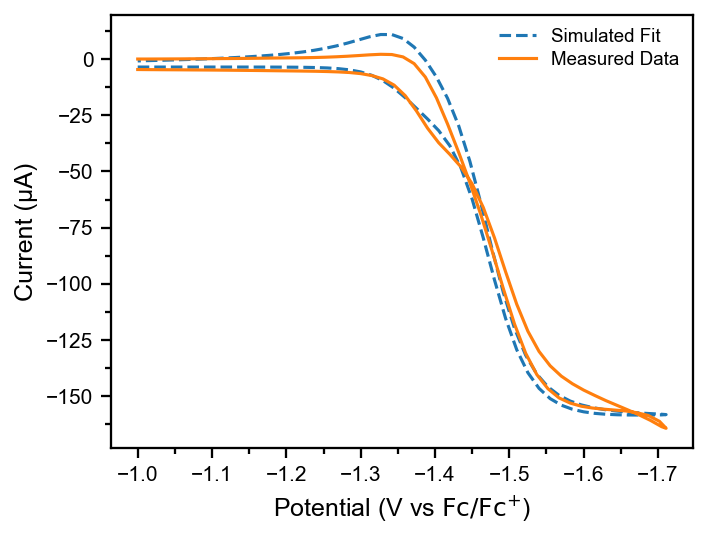

In [8]:
eecat_params = deepcopy(single_ar_fit.best_params)
eecat_params.setdefault("concentrations", {}).setdefault("bulk", {}).update({
    "Substrate": 2800.0,
    "Product": 0.0,
})
reference_diffusion = next(iter(eecat_params.get("diffusion", {"FeII": 1e-9}).values()))
eecat_params.setdefault("diffusion", {}).update({
    "Substrate": reference_diffusion,
    "Product": reference_diffusion,
})
eecat_params["reactions"] = [{"kf": 1.0, "kb": 0.0}]
eecat_params["cell"] = "auto"

eecat_mechanism = (
    "E(1):FeII=FeI\n"
    "E(1):FeI=Fe0\n"
    "C:Fe0+Substrate>FeI+Product"
)

phoh_28m_fit = e.simulation.fit_cv(
    phoh_28m_cv,
    eecat_mechanism,
    eecat_params,
    fit={
        "vary": ["reactions.0.kf"],
        "fixed": {"alpha_*": 0.5, "k0_*": 1e-3},
        "bounds": "auto",
        "transform": "auto",
    },
    options={
        "cv data": {**PHOH_CV_WINDOW_OPTIONS, "stride": CO2_FIT_STRIDE, "estimate Cdl": "auto"},
        "concentration mapping": {"PhOH": "Substrate"},
        "plot": True,
        "post correction": "offset",
        "print stats": False,
        "print corrections": False,
        "print progress": False,
    },
)
phoh_28m_fit.show({"print setup": False, "print stats": True, "print corrections": True, "print params": True, "print simulation": False})


## Simulated EEC' Scan-Rate Sweep

Use the fitted 2.8 M PhOH result as a template and rerun the same simulated CV input at several scan rates. This is a simulation-only sweep; group fitting measured scan-rate series is covered in `09_group_fitting.ipynb`.


,scan rate / V s^-1,points,current min / A,current max / A
0,0.025,97,-0.000108,0.000008
1,0.050,97,-0.000133,0.000010
2,0.100,97,-0.000155,0.000014
3,0.250,97,-0.000177,0.000023
4,0.500,97,-0.000189,0.000032
5,1.000,97,-0.000201,0.000044


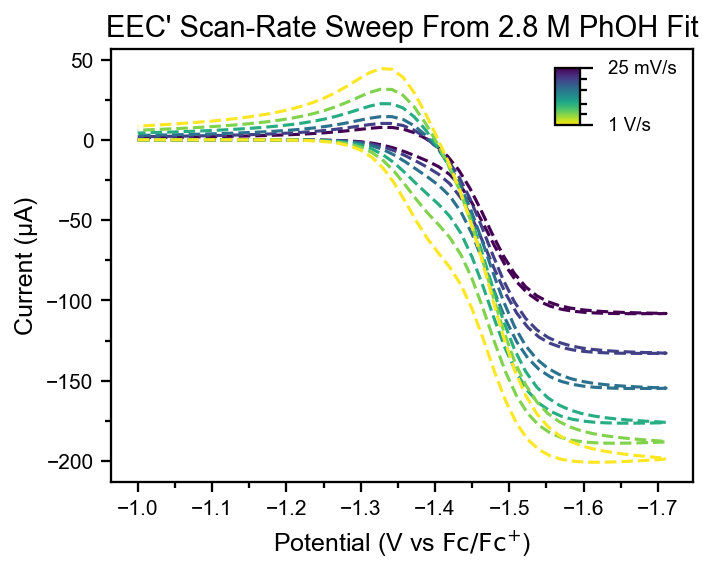

In [9]:
EECAT_SCAN_RATES = [0.025, 0.05, 0.1, 0.25, 0.5, 1.0]

scan_rate_results = [
    phoh_28m_fit.simulation_result.with_scan_rate(scan_rate, options={"plot": False})
    for scan_rate in EECAT_SCAN_RATES
]
scan_rate_labels = [f"{scan_rate:g} V/s" for scan_rate in EECAT_SCAN_RATES]

ax = e.multiplot(scan_rate_results, {
    "labels": scan_rate_labels,
    "title": "EEC' Scan-Rate Sweep From 2.8 M PhOH Fit",
    "print": False,
})

rows = []
for scan_rate, result in zip(EECAT_SCAN_RATES, scan_rate_results):
    rows.append({
        "scan rate / V s^-1": scan_rate,
        "points": len(result.data),
        "current min / A": result.data["Current"].min(),
        "current max / A": result.data["Current"].max(),
    })

display(pd.DataFrame(rows))
